# Benchmarking Classical ML Models vs Deep Learning

This notebook trains two classical ML models on the same window-based dataset used by the deep model and compares performance.

Pipeline:
1. Load train/test window arrays
2. Build tabular features from each window
3. Split training set into fit/calibration
4. Train two classical models
5. Tune decision thresholds on calibration set
6. Evaluate on test set and compare with deep learning metrics

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

DATA_DIR = "../data"
FIG_DIR = "../paper/images"
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load the same windows used in deep learning notebook
X_train = np.load(f"{DATA_DIR}/X_train.npy")
y_train = np.load(f"{DATA_DIR}/y_train.npy")
X_test = np.load(f"{DATA_DIR}/X_test.npy")
y_test = np.load(f"{DATA_DIR}/y_test.npy")

print(f"X_train: {X_train.shape} | leak ratio: {y_train.mean():.4f}")
print(f"X_test : {X_test.shape} | leak ratio: {y_test.mean():.4f}")


def window_to_tabular_features(X):
    """Convert 3D windows (n, t, f) into compact tabular descriptors."""
    mean_feat = X.mean(axis=1)
    std_feat = X.std(axis=1)
    min_feat = X.min(axis=1)
    max_feat = X.max(axis=1)
    trend_feat = X[:, -1, :] - X[:, 0, :]
    return np.concatenate([mean_feat, std_feat, min_feat, max_feat, trend_feat], axis=1)


X_train_tab = window_to_tabular_features(X_train)
X_test_tab = window_to_tabular_features(X_test)

print(f"Tabular train shape: {X_train_tab.shape}")
print(f"Tabular test  shape: {X_test_tab.shape}")

X_train: (863, 20, 6) | leak ratio: 0.3812
X_test : (221, 20, 6) | leak ratio: 0.4118
Tabular train shape: (863, 30)
Tabular test  shape: (221, 30)


In [3]:
# Internal calibration split from train only (same philosophy as deep model notebook)
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train_tab,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

print(f"X_fit: {X_fit.shape} | leak ratio: {y_fit.mean():.4f}")
print(f"X_cal: {X_cal.shape} | leak ratio: {y_cal.mean():.4f}")

X_fit: (690, 30) | leak ratio: 0.3812
X_cal: (173, 30) | leak ratio: 0.3815


In [4]:
def select_best_f1_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    if thresholds.size == 0:
        return 0.5

    p = precision[:-1]
    r = recall[:-1]
    f1 = 2 * p * r / (p + r + 1e-8)
    best_idx = int(np.nanargmax(f1))
    return float(thresholds[best_idx])


def evaluate_model(y_true, y_proba, threshold, model_name):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "Model": model_name,
        "Threshold": float(threshold),
        "AUC-ROC": float(roc_auc_score(y_true, y_proba)),
        "AUC-PR": float(average_precision_score(y_true, y_proba)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision (Leak)": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall (Leak)": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1-score (Leak)": float(f1_score(y_true, y_pred, zero_division=0)),
        "False Alarm Rate": float(fp / (fp + tn + 1e-8)),
        "Miss Rate": float(fn / (fn + tp + 1e-8)),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
    }
    return metrics, cm


models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

benchmark_rows = []
cm_by_model = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_fit, y_fit)

    y_cal_proba = model.predict_proba(X_cal)[:, 1]
    threshold = select_best_f1_threshold(y_cal, y_cal_proba)

    y_test_proba = model.predict_proba(X_test_tab)[:, 1]
    row, cm = evaluate_model(y_test, y_test_proba, threshold, name)

    benchmark_rows.append(row)
    cm_by_model[name] = cm
    trained_models[name] = model

    print("=" * 60)
    print(f"{name}")
    print(f"Selected threshold (calibration): {threshold:.4f}")
    print(f"AUC-ROC: {row['AUC-ROC']:.4f} | AUC-PR: {row['AUC-PR']:.4f}")
    print(f"Precision: {row['Precision (Leak)']:.4f} | Recall: {row['Recall (Leak)']:.4f} | F1: {row['F1-score (Leak)']:.4f}")
    print(classification_report(y_test, (y_test_proba >= threshold).astype(int), target_names=["Normal", "Leak"], digits=4, zero_division=0))

Logistic Regression
Selected threshold (calibration): 0.3752
AUC-ROC: 0.9524 | AUC-PR: 0.9595
Precision: 0.9405 | Recall: 0.8681 | F1: 0.9029
              precision    recall  f1-score   support

      Normal     0.9124    0.9615    0.9363       130
        Leak     0.9405    0.8681    0.9029        91

    accuracy                         0.9231       221
   macro avg     0.9264    0.9148    0.9196       221
weighted avg     0.9240    0.9231    0.9225       221

Random Forest
Selected threshold (calibration): 0.3695
AUC-ROC: 0.9710 | AUC-PR: 0.9652
Precision: 0.9487 | Recall: 0.8132 | F1: 0.8757
              precision    recall  f1-score   support

      Normal     0.8811    0.9692    0.9231       130
        Leak     0.9487    0.8132    0.8757        91

    accuracy                         0.9050       221
   macro avg     0.9149    0.8912    0.8994       221
weighted avg     0.9090    0.9050    0.9036       221



In [5]:
# Load deep learning metrics and create unified benchmark table
benchmark_df = pd.DataFrame(benchmark_rows)

deep_metrics_path = f"{DATA_DIR}/final_metrics.csv"
if os.path.exists(deep_metrics_path):
    deep_raw = pd.read_csv(deep_metrics_path)
    deep_row = {"Model": "Deep Learning (CNN-BiLSTM-Attention)"}
    for _, r in deep_raw.iterrows():
        metric = str(r["Metric"])
        value = r["Value"]
        if metric in [
            "Threshold",
            "AUC-ROC",
            "AUC-PR",
            "Accuracy",
            "Balanced Accuracy",
            "Precision (Leak)",
            "Recall (Leak)",
            "F1-score (Leak)",
            "False Alarm Rate",
            "Miss Rate",
            "TP",
            "FP",
            "TN",
            "FN",
        ]:
            deep_row[metric] = value

    benchmark_df = pd.concat([benchmark_df, pd.DataFrame([deep_row])], ignore_index=True)
    print("Deep learning metrics loaded from final_metrics.csv")
else:
    print("Warning: final_metrics.csv not found. Deep model row will be missing.")

ordered_cols = [
    "Model",
    "Threshold",
    "AUC-ROC",
    "AUC-PR",
    "Accuracy",
    "Balanced Accuracy",
    "Precision (Leak)",
    "Recall (Leak)",
    "F1-score (Leak)",
    "False Alarm Rate",
    "Miss Rate",
    "TP",
    "FP",
    "TN",
    "FN",
]

benchmark_df = benchmark_df[[c for c in ordered_cols if c in benchmark_df.columns]]
benchmark_df = benchmark_df.sort_values(by=["AUC-PR", "F1-score (Leak)"], ascending=False).reset_index(drop=True)

print("\n=== BENCHMARK RESULTS (sorted by AUC-PR then F1) ===")
print(benchmark_df.round(4).to_string(index=False))

Deep learning metrics loaded from final_metrics.csv

=== BENCHMARK RESULTS (sorted by AUC-PR then F1) ===
                               Model  Threshold  AUC-ROC  AUC-PR  Accuracy  Balanced Accuracy  Precision (Leak)  Recall (Leak)  F1-score (Leak)  False Alarm Rate  Miss Rate   TP  FP    TN   FN
                       Random Forest     0.3695   0.9710  0.9652    0.9050             0.8912            0.9487         0.8132           0.8757            0.0308     0.1868 74.0 4.0 126.0 17.0
                 Logistic Regression     0.3752   0.9524  0.9595    0.9231             0.9148            0.9405         0.8681           0.9029            0.0385     0.1319 79.0 5.0 125.0 12.0
Deep Learning (CNN-BiLSTM-Attention)     0.0333   0.9412  0.9583    0.9457             0.9390            0.9647         0.9011           0.9318            0.0231     0.0989 82.0 3.0 127.0  9.0


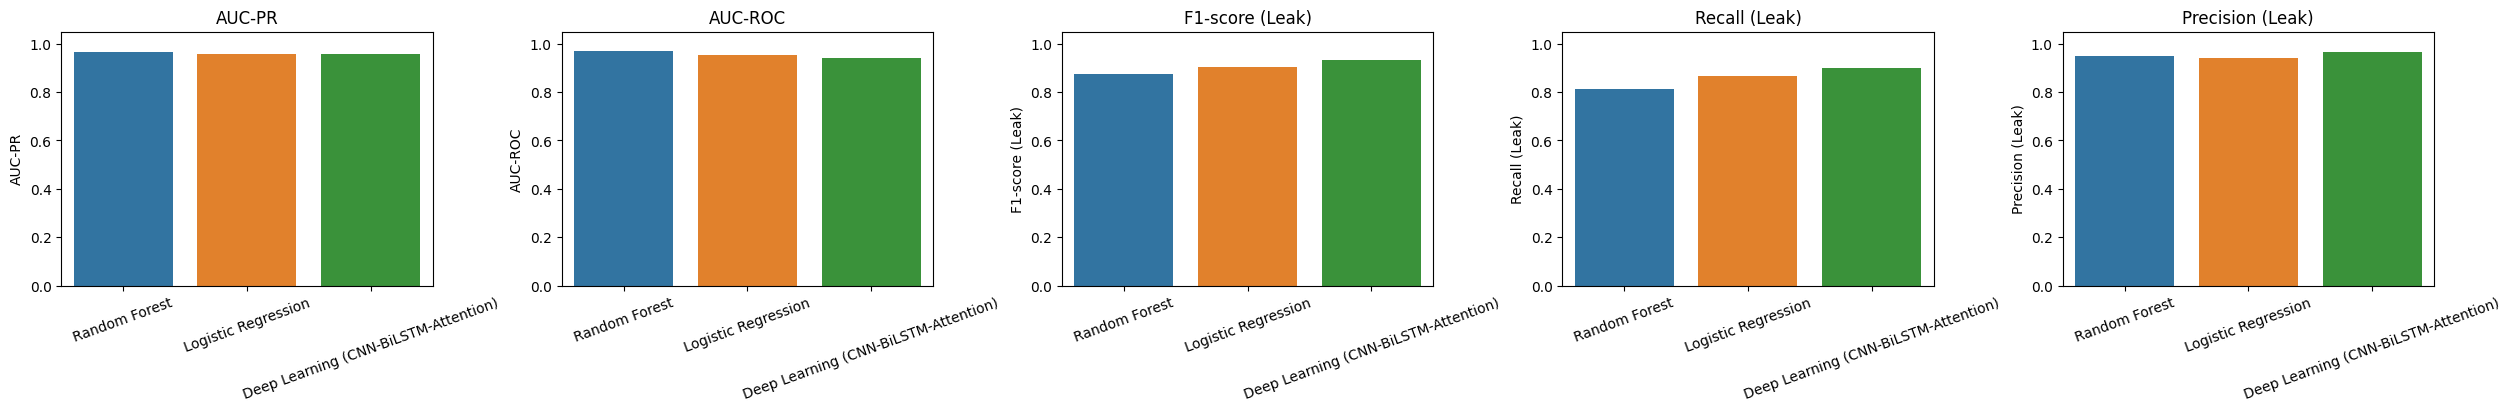

In [6]:
# Visual benchmark for key metrics
plot_metrics = ["AUC-PR", "AUC-ROC", "F1-score (Leak)", "Recall (Leak)", "Precision (Leak)"]
plot_df = benchmark_df[["Model"] + [m for m in plot_metrics if m in benchmark_df.columns]].copy()

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(5 * len(plot_metrics), 4), constrained_layout=True)
if len(plot_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, plot_metrics):
    if metric not in plot_df.columns:
        ax.axis("off")
        continue
    sns.barplot(data=plot_df, x="Model", y=metric, ax=ax, hue="Model", legend=False)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)

plt.savefig(f"{FIG_DIR}/fig_benchmark_classical_vs_deep.png", dpi=300, bbox_inches="tight")
plt.show()

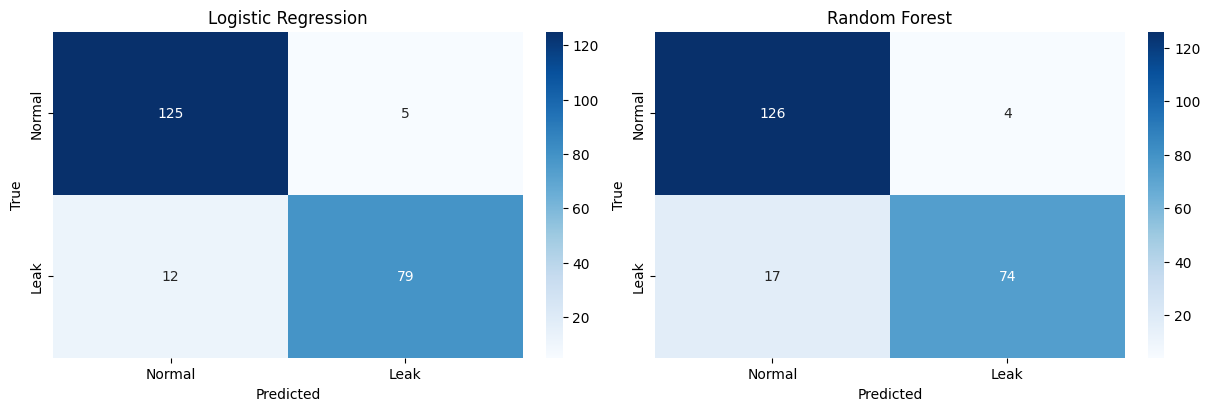

In [7]:
# Confusion matrices for classical models
fig, axes = plt.subplots(1, len(cm_by_model), figsize=(6 * len(cm_by_model), 4), constrained_layout=True)
if len(cm_by_model) == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, cm_by_model.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Leak"],
        yticklabels=["Normal", "Leak"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.savefig(f"{FIG_DIR}/fig_benchmark_confusion_matrices_classical.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Save benchmark outputs
benchmark_df.to_csv(f"{DATA_DIR}/benchmark_metrics_all_models.csv", index=False)

# Optional: classical models only, easier for focused comparisons
benchmark_df[benchmark_df["Model"].isin(["Logistic Regression", "Random Forest"])].to_csv(
    f"{DATA_DIR}/benchmark_metrics_classical_models.csv",
    index=False,
)

print(f"Saved -> {DATA_DIR}/benchmark_metrics_all_models.csv")
print(f"Saved -> {DATA_DIR}/benchmark_metrics_classical_models.csv")

Saved -> ../data/benchmark_metrics_all_models.csv
Saved -> ../data/benchmark_metrics_classical_models.csv
